In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Create folder to save our fake images ──────────────────────────────────
os.makedirs("../data/fake_satellite", exist_ok=True)

# ── Helper: make one fake satellite image ──────────────────────────────────
def make_fake_satellite(day, size=256):
    """
    Generates a fake satellite image that slowly changes over time.
    day = 0 means early in the season (less vegetation)
    day = 1 means late  in the season (more vegetation)
    """
    np.random.seed(int(day * 100))
    img = np.zeros((size, size, 3), dtype=np.float32)

    # Background land colour (browns/tans)
    img[:, :, 0] = 0.55 + np.random.normal(0, 0.03, (size, size))  # Red
    img[:, :, 1] = 0.45 + np.random.normal(0, 0.03, (size, size))  # Green
    img[:, :, 2] = 0.30 + np.random.normal(0, 0.03, (size, size))  # Blue

    # Vegetation patch (top-left quadrant) — grows greener over time
    veg_strength = 0.15 + day * 0.25          # more green later in season
    img[:size//2, :size//2, 1] += veg_strength # boost green channel
    img[:size//2, :size//2, 0] -= veg_strength * 0.4

    # Water body (bottom-right) — stays blue/dark throughout
    img[size//2:, size//2:, 2] = 0.55 + np.random.normal(0, 0.01, (size//2, size//2))
    img[size//2:, size//2:, 0] = 0.10
    img[size//2:, size//2:, 1] = 0.20

    # Urban area (top-right) — slight grey, doesn't change much
    img[:size//2, size//2:, 0] = 0.60 + np.random.normal(0, 0.02, (size//2, size//2))
    img[:size//2, size//2:, 1] = 0.58 + np.random.normal(0, 0.02, (size//2, size//2))
    img[:size//2, size//2:, 2] = 0.58 + np.random.normal(0, 0.02, (size//2, size//2))

    # Clip to valid range 0-1
    img = np.clip(img, 0, 1)
    return img

# ── Generate Day 1, Day 5 (hidden truth), Day 10 ───────────────────────────
day1  = make_fake_satellite(day=0.0)    # early season
day5  = make_fake_satellite(day=0.5)    # mid season (this is what we'll predict)
day10 = make_fake_satellite(day=1.0)    # late season

# ── Save them ──────────────────────────────────────────────────────────────
def save_img(arr, path):
    plt.imsave(path, arr)

save_img(day1,  "../data/fake_satellite/day01.png")
save_img(day5,  "../data/fake_satellite/day05_hidden_truth.png")
save_img(day10, "../data/fake_satellite/day10.png")

print("✅ Fake satellite images saved!")
print("📁 Location: data/fake_satellite/")

✅ Fake satellite images saved!
📁 Location: data/fake_satellite/


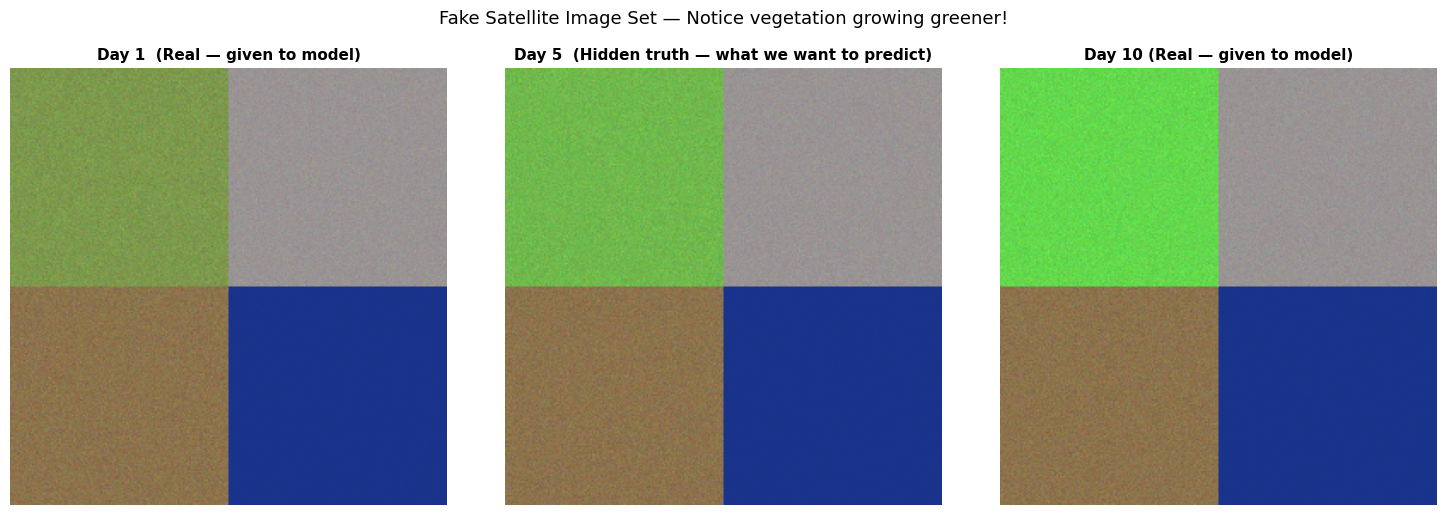


🗺️  What each region represents:
  Top-Left    → Vegetation / Farmland  (gets greener Day 1 → Day 10)
  Top-Right   → Urban / Built-up area  (stays similar)
  Bottom-Left → Bare soil / Desert     (stays brownish)
  Bottom-Right→ Water body / Lake      (stays dark blue)


In [3]:
# ── Display all three images side by side ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [day1, day5, day10]
titles = [
    "Day 1  (Real — given to model)",
    "Day 5  (Hidden truth — what we want to predict)",
    "Day 10 (Real — given to model)"
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Fake Satellite Image Set — Notice vegetation growing greener!", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n🗺️  What each region represents:")
print("  Top-Left    → Vegetation / Farmland  (gets greener Day 1 → Day 10)")
print("  Top-Right   → Urban / Built-up area  (stays similar)")
print("  Bottom-Left → Bare soil / Desert     (stays brownish)")
print("  Bottom-Right→ Water body / Lake      (stays dark blue)")

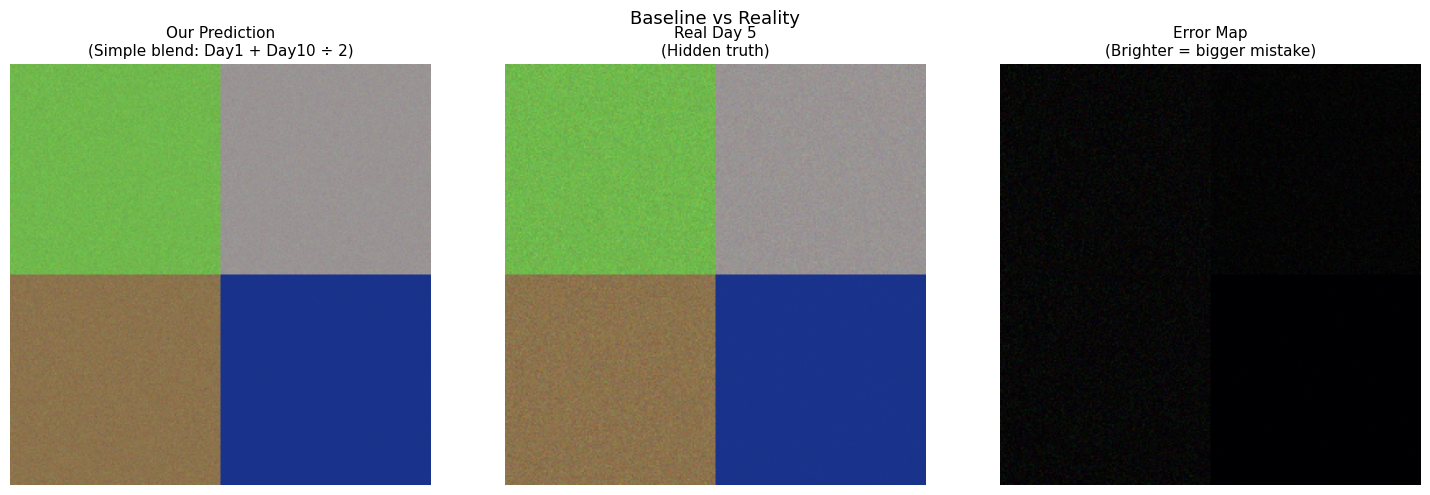


📊 Baseline accuracy score (PSNR): 30.78 dB
   (Higher is better. Our AI model will aim to beat this number.)


In [4]:
# ── Baseline prediction: simple 50/50 blend ────────────────────────────────
day5_predicted_baseline = (day1 + day10) / 2.0

# ── Compare prediction vs real hidden truth ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(day5_predicted_baseline)
axes[0].set_title("Our Prediction\n(Simple blend: Day1 + Day10 ÷ 2)", fontsize=11)
axes[0].axis('off')

axes[1].imshow(day5)
axes[1].set_title("Real Day 5\n(Hidden truth)", fontsize=11)
axes[1].axis('off')

# Difference map — shows where we got it wrong
diff = np.abs(day5_predicted_baseline - day5)
axes[2].imshow(diff, cmap='hot')
axes[2].set_title("Error Map\n(Brighter = bigger mistake)", fontsize=11)
axes[2].axis('off')

plt.suptitle("Baseline vs Reality", fontsize=13)
plt.tight_layout()
plt.show()

# ── Compute accuracy score ─────────────────────────────────────────────────
mse  = np.mean((day5_predicted_baseline - day5) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')
print(f"\n📊 Baseline accuracy score (PSNR): {psnr:.2f} dB")
print("   (Higher is better. Our AI model will aim to beat this number.)")